# Part 2d: Custom Layers in Deep Learning

## Overview

In this notebook, we'll explore how to create **custom layers** in both TensorFlow/Keras and PyTorch. Custom layers allow you to implement novel architectures and specialized operations not available in standard libraries.

### Topics Covered:
1. **Exponential Layer** - A simple non-parametric layer
2. **MyDense Layer** - Custom fully-connected layer with various features
3. **AddGaussianNoise** - Regularization through noise injection
4. **LayerNormalization** - Custom implementation of layer normalization
5. **MaxNormDense** - Dense layer with max-norm constraint

### Why Custom Layers?
- Implement novel research ideas
- Optimize for specific use cases
- Add custom constraints and regularization
- Better understand how layers work internally

In [1]:
# Install required packages (for Google Colab)
!pip install -q tensorflow torch matplotlib seaborn

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers, regularizers, constraints
from tensorflow.keras import backend as K

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")

TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cu128


---

## 1. Understanding Custom Layers

### Layer Architecture

A layer typically consists of:
- **Weights**: Trainable parameters learned during training
- **Forward pass**: The computation performed on input data
- **Backward pass**: Gradient computation (handled automatically)

### TensorFlow vs PyTorch Layer Structure

| Aspect | TensorFlow/Keras | PyTorch |
|--------|-----------------|--------|
| Base class | `keras.layers.Layer` | `nn.Module` |
| Weight creation | `build()` or `__init__` with `add_weight()` | `__init__` with `nn.Parameter` |
| Forward pass | `call()` | `forward()` |
| Training mode | `training` argument | `self.training` attribute |

---

## 2. Exponential Layer

A simple layer that applies the exponential function element-wise. This is a **non-parametric layer** (no trainable weights).

### 2.1 TensorFlow/Keras Implementation

In [3]:
class ExponentialLayer(keras.layers.Layer):
    """
    Custom layer that applies exponential transformation.

    This is a simple non-parametric layer demonstrating the basic
    structure of custom Keras layers.

    Output: exp(input)
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        """Apply exponential transformation."""
        return tf.exp(inputs)

    def compute_output_shape(self, input_shape):
        """Output shape is same as input shape."""
        return input_shape

    def get_config(self):
        """Return config for serialization."""
        return super().get_config()

In [4]:
# Test ExponentialLayer
print("Testing TensorFlow ExponentialLayer:")
print("=" * 50)

exp_layer = ExponentialLayer()
test_input = tf.constant([[1.0, 2.0], [0.0, -1.0]])
output = exp_layer(test_input)

print(f"Input:\n{test_input.numpy()}")
print(f"\nOutput (exp of input):\n{output.numpy()}")
print(f"\nExpected (np.exp):\n{np.exp(test_input.numpy())}")

Testing TensorFlow ExponentialLayer:
Input:
[[ 1.  2.]
 [ 0. -1.]]

Output (exp of input):
[[2.7182817  7.389056  ]
 [1.         0.36787948]]

Expected (np.exp):
[[2.718282   7.3890557 ]
 [1.         0.36787942]]


### 2.2 PyTorch Implementation

In [5]:
class ExponentialLayerPyTorch(nn.Module):
    """
    PyTorch implementation of Exponential Layer.
    """

    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.exp(x)

In [6]:
# Test PyTorch ExponentialLayer
exp_layer_pt = ExponentialLayerPyTorch()
test_input_pt = torch.tensor([[1.0, 2.0], [0.0, -1.0]])
output_pt = exp_layer_pt(test_input_pt)

print("Testing PyTorch ExponentialLayer:")
print(f"Output:\n{output_pt.numpy()}")

Testing PyTorch ExponentialLayer:
Output:
[[2.7182817  7.389056  ]
 [1.         0.36787945]]


---

## 3. MyDense Layer (Custom Fully-Connected Layer)

A full-featured custom dense layer with:
- Configurable units and activation
- Support for kernel/bias initializers
- Regularization support
- Constraint support

### 3.1 TensorFlow/Keras Implementation

In [7]:
class MyDense(keras.layers.Layer):
    """
    Custom Dense (Fully-Connected) Layer.

    Implements: output = activation(input @ kernel + bias)

    Parameters:
    -----------
    units : int
        Number of output units
    activation : str or callable
        Activation function
    use_bias : bool
        Whether to use bias
    kernel_initializer : str or initializer
        Initializer for kernel weights
    bias_initializer : str or initializer
        Initializer for bias
    kernel_regularizer : regularizer
        Regularizer for kernel
    kernel_constraint : constraint
        Constraint for kernel
    """

    def __init__(self,
                 units,
                 activation=None,
                 use_bias=True,
                 kernel_initializer='glorot_uniform',
                 bias_initializer='zeros',
                 kernel_regularizer=None,
                 bias_regularizer=None,
                 kernel_constraint=None,
                 bias_constraint=None,
                 **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)
        self.use_bias = use_bias
        self.kernel_initializer = keras.initializers.get(kernel_initializer)
        self.bias_initializer = keras.initializers.get(bias_initializer)
        self.kernel_regularizer = keras.regularizers.get(kernel_regularizer)
        self.bias_regularizer = keras.regularizers.get(bias_regularizer)
        self.kernel_constraint = keras.constraints.get(kernel_constraint)
        self.bias_constraint = keras.constraints.get(bias_constraint)

    def build(self, input_shape):
        """
        Create layer weights.

        This is called the first time the layer is used.
        """
        input_dim = input_shape[-1]

        # Create kernel weight
        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_dim, self.units),
            initializer=self.kernel_initializer,
            regularizer=self.kernel_regularizer,
            constraint=self.kernel_constraint,
            trainable=True
        )

        # Create bias weight
        if self.use_bias:
            self.bias = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer=self.bias_initializer,
                regularizer=self.bias_regularizer,
                constraint=self.bias_constraint,
                trainable=True
            )
        else:
            self.bias = None

        # Mark layer as built
        super().build(input_shape)

    def call(self, inputs):
        """Forward pass."""
        # Matrix multiplication
        output = tf.matmul(inputs, self.kernel)

        # Add bias
        if self.use_bias:
            output = output + self.bias

        # Apply activation
        if self.activation is not None:
            output = self.activation(output)

        return output

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.units,)

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': keras.activations.serialize(self.activation),
            'use_bias': self.use_bias,
            'kernel_initializer': keras.initializers.serialize(self.kernel_initializer),
            'bias_initializer': keras.initializers.serialize(self.bias_initializer),
            'kernel_regularizer': keras.regularizers.serialize(self.kernel_regularizer),
            'bias_regularizer': keras.regularizers.serialize(self.bias_regularizer),
            'kernel_constraint': keras.constraints.serialize(self.kernel_constraint),
            'bias_constraint': keras.constraints.serialize(self.bias_constraint),
        })
        return config

In [8]:
# Test MyDense layer
print("Testing TensorFlow MyDense Layer:")
print("=" * 50)

# Create layer
my_dense = MyDense(
    units=64,
    activation='relu',
    kernel_initializer='he_normal',
    kernel_regularizer=keras.regularizers.l2(0.01)
)

# Test with sample input
test_input = tf.random.normal((32, 128))
output = my_dense(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Kernel shape: {my_dense.kernel.shape}")
print(f"Bias shape: {my_dense.bias.shape}")
print(f"Trainable parameters: {my_dense.count_params()}")

Testing TensorFlow MyDense Layer:
Input shape: (32, 128)
Output shape: (32, 64)
Kernel shape: (128, 64)
Bias shape: (64,)
Trainable parameters: 8256


In [9]:
# Compare MyDense with Keras Dense
print("\nComparing MyDense with Keras Dense:")
print("=" * 50)

# Build model with MyDense
model_custom = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    MyDense(256, activation='relu'),
    MyDense(128, activation='relu'),
    MyDense(10, activation='softmax')
])

# Build model with standard Dense
model_standard = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

print(f"MyDense model parameters: {model_custom.count_params()}")
print(f"Standard Dense parameters: {model_standard.count_params()}")

model_custom.summary()


Comparing MyDense with Keras Dense:
MyDense model parameters: 235146
Standard Dense parameters: 235146


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_dense_1 (MyDense)            │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_2 (MyDense)            │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_3 (MyDense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 PyTorch Implementation

In [10]:
class MyDensePyTorch(nn.Module):
    """
    Custom Dense (Fully-Connected) Layer for PyTorch.

    Parameters:
    -----------
    in_features : int
        Number of input features
    out_features : int
        Number of output features
    bias : bool
        Whether to include bias
    activation : str
        Activation function name
    """

    def __init__(self, in_features, out_features, bias=True, activation=None):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.use_bias = bias

        # Create weight parameters
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter('bias', None)

        # Set activation
        if activation == 'relu':
            self.activation = F.relu
        elif activation == 'sigmoid':
            self.activation = torch.sigmoid
        elif activation == 'tanh':
            self.activation = torch.tanh
        elif activation == 'softmax':
            self.activation = lambda x: F.softmax(x, dim=-1)
        else:
            self.activation = None

        # Initialize weights
        self._reset_parameters()

    def _reset_parameters(self):
        """Initialize weights using Kaiming uniform."""
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        """Forward pass."""
        output = F.linear(x, self.weight, self.bias)
        if self.activation is not None:
            output = self.activation(output)
        return output

    def extra_repr(self):
        return f'in_features={self.in_features}, out_features={self.out_features}, bias={self.use_bias}'

In [11]:
# Test PyTorch MyDense
print("Testing PyTorch MyDense Layer:")
print("=" * 50)

my_dense_pt = MyDensePyTorch(128, 64, activation='relu')
test_input_pt = torch.randn(32, 128)
output_pt = my_dense_pt(test_input_pt)

print(f"Input shape: {test_input_pt.shape}")
print(f"Output shape: {output_pt.shape}")
print(f"Weight shape: {my_dense_pt.weight.shape}")
print(f"Bias shape: {my_dense_pt.bias.shape}")
print(f"\nLayer info: {my_dense_pt}")

Testing PyTorch MyDense Layer:
Input shape: torch.Size([32, 128])
Output shape: torch.Size([32, 64])
Weight shape: torch.Size([64, 128])
Bias shape: torch.Size([64])

Layer info: MyDensePyTorch(in_features=128, out_features=64, bias=True)


---

## 4. AddGaussianNoise Layer

A regularization layer that adds Gaussian noise during training. This helps prevent overfitting by making the model robust to small input perturbations.

### 4.1 TensorFlow/Keras Implementation

In [12]:
class AddGaussianNoise(keras.layers.Layer):
    """
    Layer that adds Gaussian noise during training.

    This is a regularization technique that helps prevent overfitting
    by making the model robust to small perturbations.

    Compatible with Keras 3.x

    Parameters:
    -----------
    stddev : float
        Standard deviation of the noise
    """

    def __init__(self, stddev=0.1, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        """
        Add noise during training only.

        Parameters:
        -----------
        inputs : tensor
            Input tensor
        training : bool
            Whether in training mode
        """
        if training is None:
            training = False

        if not training:
            return inputs

        # Add Gaussian noise during training
        noise = tf.random.normal(
            shape=tf.shape(inputs),
            mean=0.0,
            stddev=self.stddev,
            dtype=inputs.dtype
        )
        return inputs + noise

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super().get_config()
        config.update({'stddev': self.stddev})
        return config

In [13]:
# Test AddGaussianNoise
print("Testing TensorFlow AddGaussianNoise Layer:")
print("=" * 50)

noise_layer = AddGaussianNoise(stddev=0.5)
test_input = tf.ones((4, 4))

# Training mode
output_train = noise_layer(test_input, training=True)
# Inference mode
output_infer = noise_layer(test_input, training=False)

print(f"Input:\n{test_input.numpy()}")
print(f"\nOutput (training=True):\n{output_train.numpy()}")
print(f"\nOutput (training=False):\n{output_infer.numpy()}")
print(f"\nNoise stddev (training): {np.std(output_train.numpy() - 1):.4f}")

Testing TensorFlow AddGaussianNoise Layer:
Input:
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

Output (training=True):
[[ 1.0421124   0.56954813  1.1890615   0.99740183]
 [ 0.752734    1.3089097   0.8345898   0.99930793]
 [ 0.78813297  0.30639565  0.22559047  0.7340081 ]
 [ 0.7762178  -0.00579071  0.71036994  1.2896945 ]]

Output (training=False):
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

Noise stddev (training): 0.3601


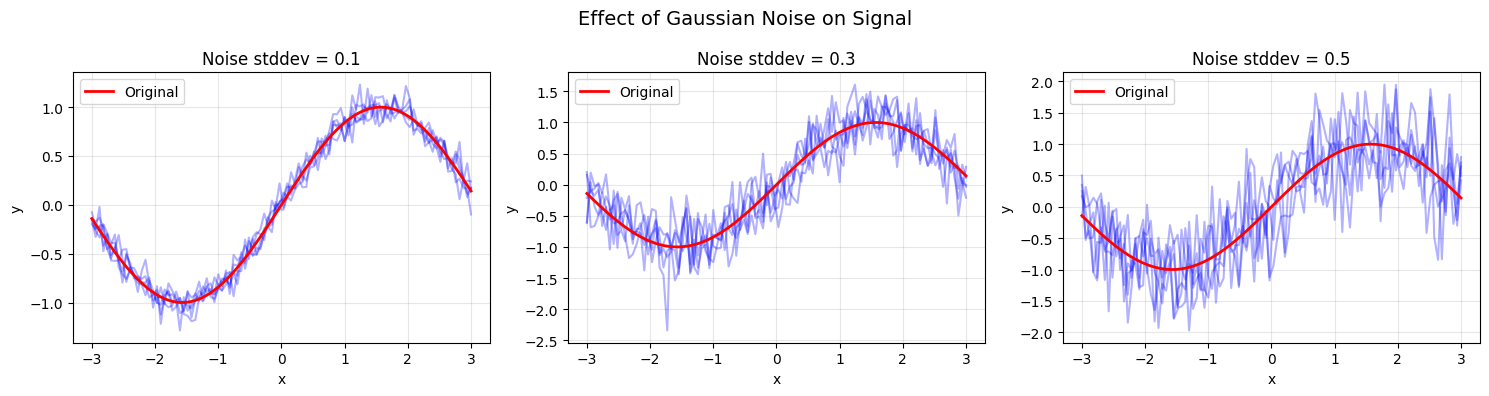

In [14]:
# Visualize noise effect
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Generate sample data
x = np.linspace(-3, 3, 100)
y_clean = np.sin(x)

# Different noise levels
noise_levels = [0.1, 0.3, 0.5]

for ax, stddev in zip(axes, noise_levels):
    noise_layer = AddGaussianNoise(stddev=stddev)

    # Plot multiple noisy versions
    for i in range(5):
        y_noisy = noise_layer(tf.constant(y_clean, dtype=tf.float32), training=True).numpy()
        ax.plot(x, y_noisy, alpha=0.3, color='blue')

    ax.plot(x, y_clean, 'r-', linewidth=2, label='Original')
    ax.set_title(f'Noise stddev = {stddev}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Gaussian Noise on Signal', fontsize=14)
plt.tight_layout()
plt.show()

### 4.2 PyTorch Implementation

In [15]:
class AddGaussianNoisePyTorch(nn.Module):
    """
    PyTorch layer that adds Gaussian noise during training.
    """

    def __init__(self, stddev=0.1):
        super().__init__()
        self.stddev = stddev

    def forward(self, x):
        """Add noise only during training."""
        if self.training:
            noise = torch.randn_like(x) * self.stddev
            return x + noise
        return x

    def extra_repr(self):
        return f'stddev={self.stddev}'

In [16]:
# Test PyTorch noise layer
print("Testing PyTorch AddGaussianNoise Layer:")
print("=" * 50)

noise_layer_pt = AddGaussianNoisePyTorch(stddev=0.5)
test_input_pt = torch.ones(4, 4)

# Training mode
noise_layer_pt.train()
output_train_pt = noise_layer_pt(test_input_pt)

# Eval mode
noise_layer_pt.eval()
output_eval_pt = noise_layer_pt(test_input_pt)

print(f"Output (training mode):\n{output_train_pt}")
print(f"\nOutput (eval mode):\n{output_eval_pt}")

Testing PyTorch AddGaussianNoise Layer:
Output (training mode):
tensor([[1.7848, 2.0605, 1.2015, 1.0634],
        [1.1322, 1.3579, 0.5930, 0.9508],
        [0.6609, 0.8967, 0.2184, 0.5404],
        [0.3279, 2.0226, 1.5608, 0.7726]])

Output (eval mode):
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


---

## 5. Custom LayerNormalization

Layer Normalization normalizes across the feature dimension, making it suitable for RNNs and Transformers where batch normalization is problematic.

### Mathematical Definition:

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

where $\mu$ and $\sigma^2$ are computed across the feature dimension.

### 5.1 TensorFlow/Keras Implementation

In [17]:
class MyLayerNormalization(keras.layers.Layer):
    """
    Custom Layer Normalization implementation.

    Normalizes across the last axis (features) of the input.

    Parameters:
    -----------
    epsilon : float
        Small constant for numerical stability
    center : bool
        Whether to add learnable offset (beta)
    scale : bool
        Whether to add learnable scale (gamma)
    """

    def __init__(self, epsilon=1e-6, center=True, scale=True, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon
        self.center = center
        self.scale = scale

    def build(self, input_shape):
        """Create gamma and beta parameters."""
        # Shape of normalization parameters
        param_shape = input_shape[-1:]

        if self.scale:
            self.gamma = self.add_weight(
                name='gamma',
                shape=param_shape,
                initializer='ones',
                trainable=True
            )
        else:
            self.gamma = None

        if self.center:
            self.beta = self.add_weight(
                name='beta',
                shape=param_shape,
                initializer='zeros',
                trainable=True
            )
        else:
            self.beta = None

        super().build(input_shape)

    def call(self, inputs):
        """Apply layer normalization."""
        # Compute mean and variance across last axis
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)

        # Normalize
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)

        # Scale and shift
        if self.scale:
            normalized = normalized * self.gamma
        if self.center:
            normalized = normalized + self.beta

        return normalized

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super().get_config()
        config.update({
            'epsilon': self.epsilon,
            'center': self.center,
            'scale': self.scale
        })
        return config

In [18]:
# Test MyLayerNormalization
print("Testing TensorFlow MyLayerNormalization:")
print("=" * 50)

# Create test input with known statistics
test_input = tf.constant([[1.0, 2.0, 3.0, 4.0],
                          [5.0, 6.0, 7.0, 8.0]])

# Custom layer
my_ln = MyLayerNormalization()
output_custom = my_ln(test_input)

# Built-in layer for comparison
builtin_ln = keras.layers.LayerNormalization()
output_builtin = builtin_ln(test_input)

print(f"Input:\n{test_input.numpy()}")
print(f"\nCustom LayerNorm output:\n{output_custom.numpy()}")
print(f"\nBuilt-in LayerNorm output:\n{output_builtin.numpy()}")
print(f"\nDifference:\n{np.abs(output_custom.numpy() - output_builtin.numpy())}")

Testing TensorFlow MyLayerNormalization:
Input:
[[1. 2. 3. 4.]
 [5. 6. 7. 8.]]

Custom LayerNorm output:
[[-1.3416404  -0.44721344  0.44721344  1.3416404 ]
 [-1.3416404  -0.44721344  0.44721344  1.3416404 ]]

Built-in LayerNorm output:
[[-1.3411043  -0.44703472  0.44703484  1.3411045 ]
 [-1.3411045  -0.44703484  0.44703484  1.3411045 ]]

Difference:
[[0.00053608 0.00017872 0.00017861 0.00053585]
 [0.00053585 0.00017861 0.00017861 0.00053585]]


### 5.2 PyTorch Implementation

In [19]:
class MyLayerNormalizationPyTorch(nn.Module):
    """
    Custom Layer Normalization for PyTorch.
    """

    def __init__(self, normalized_shape, eps=1e-6, elementwise_affine=True):
        super().__init__()
        if isinstance(normalized_shape, int):
            normalized_shape = (normalized_shape,)
        self.normalized_shape = tuple(normalized_shape)
        self.eps = eps
        self.elementwise_affine = elementwise_affine

        if elementwise_affine:
            self.gamma = nn.Parameter(torch.ones(normalized_shape))
            self.beta = nn.Parameter(torch.zeros(normalized_shape))
        else:
            self.register_parameter('gamma', None)
            self.register_parameter('beta', None)

    def forward(self, x):
        """Apply layer normalization."""
        # Compute mean and variance
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, unbiased=False, keepdim=True)

        # Normalize
        x_norm = (x - mean) / torch.sqrt(var + self.eps)

        # Affine transformation
        if self.elementwise_affine:
            x_norm = x_norm * self.gamma + self.beta

        return x_norm

    def extra_repr(self):
        return f'{self.normalized_shape}, eps={self.eps}, elementwise_affine={self.elementwise_affine}'

In [20]:
# Test PyTorch LayerNorm
print("Testing PyTorch MyLayerNormalization:")
print("=" * 50)

test_input_pt = torch.tensor([[1.0, 2.0, 3.0, 4.0],
                               [5.0, 6.0, 7.0, 8.0]])

my_ln_pt = MyLayerNormalizationPyTorch(4)
builtin_ln_pt = nn.LayerNorm(4)

output_custom_pt = my_ln_pt(test_input_pt)
output_builtin_pt = builtin_ln_pt(test_input_pt)

print(f"Custom output:\n{output_custom_pt}")
print(f"\nBuilt-in output:\n{output_builtin_pt}")

Testing PyTorch MyLayerNormalization:
Custom output:
tensor([[-1.3416, -0.4472,  0.4472,  1.3416],
        [-1.3416, -0.4472,  0.4472,  1.3416]], grad_fn=<AddBackward0>)

Built-in output:
tensor([[-1.3416, -0.4472,  0.4472,  1.3416],
        [-1.3416, -0.4472,  0.4472,  1.3416]],
       grad_fn=<NativeLayerNormBackward0>)


---

## 6. MaxNormDense Layer

A Dense layer with max-norm weight constraint. This is a regularization technique that constrains the L2 norm of incoming weights for each neuron.

### 6.1 TensorFlow/Keras Implementation

In [21]:
class MaxNormDense(keras.layers.Layer):
    """
    Dense layer with max-norm constraint on weights.

    After each update, the weight vectors are clipped to have
    a maximum L2 norm of `max_norm`.

    Parameters:
    -----------
    units : int
        Number of output units
    max_norm : float
        Maximum L2 norm for weight vectors
    activation : str
        Activation function
    """

    def __init__(self, units, max_norm=3.0, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.max_norm = max_norm
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        input_dim = input_shape[-1]

        # Create weight with max-norm constraint
        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_dim, self.units),
            initializer='glorot_uniform',
            constraint=keras.constraints.MaxNorm(max_value=self.max_norm, axis=0),
            trainable=True
        )

        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

        super().build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.kernel) + self.bias
        if self.activation is not None:
            output = self.activation(output)
        return output

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.units,)

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'max_norm': self.max_norm,
            'activation': keras.activations.serialize(self.activation)
        })
        return config

In [22]:
# Alternative implementation with explicit max-norm enforcement
class MaxNormDenseExplicit(keras.layers.Layer):
    """
    MaxNorm Dense with explicit norm computation and clipping.
    """

    def __init__(self, units, max_norm=3.0, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.max_norm = max_norm
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_dim, self.units),
            initializer='glorot_uniform',
            trainable=True
        )

        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

        super().build(input_shape)

    def _apply_max_norm(self, weights):
        """Apply max-norm constraint to weights."""
        # Compute L2 norm along axis 0 (input dimension)
        norms = tf.sqrt(tf.reduce_sum(tf.square(weights), axis=0, keepdims=True))
        # Compute scaling factor
        desired = tf.clip_by_value(norms, 0, self.max_norm)
        # Scale weights
        return weights * (desired / (norms + 1e-8))

    def call(self, inputs, training=None):
        # Apply max-norm constraint
        constrained_kernel = self._apply_max_norm(self.kernel)

        output = tf.matmul(inputs, constrained_kernel) + self.bias
        if self.activation is not None:
            output = self.activation(output)
        return output

In [23]:
# Test MaxNormDense
print("Testing TensorFlow MaxNormDense Layer:")
print("=" * 50)

# Create and use layer
maxnorm_layer = MaxNormDense(units=32, max_norm=2.0, activation='relu')
test_input = tf.random.normal((16, 64))
output = maxnorm_layer(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")

# Check weight norms
weight_norms = tf.sqrt(tf.reduce_sum(tf.square(maxnorm_layer.kernel), axis=0))
print(f"\nWeight column norms (should be <= 2.0):")
print(f"Min: {tf.reduce_min(weight_norms).numpy():.4f}")
print(f"Max: {tf.reduce_max(weight_norms).numpy():.4f}")
print(f"Mean: {tf.reduce_mean(weight_norms).numpy():.4f}")

Testing TensorFlow MaxNormDense Layer:
Input shape: (16, 64)
Output shape: (16, 32)

Weight column norms (should be <= 2.0):
Min: 1.0497
Max: 1.2415
Mean: 1.1636


### 6.2 PyTorch Implementation

In [24]:
class MaxNormDensePyTorch(nn.Module):
    """
    PyTorch Dense layer with max-norm constraint.
    """

    def __init__(self, in_features, out_features, max_norm=3.0, activation=None):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.max_norm = max_norm

        # Linear layer
        self.linear = nn.Linear(in_features, out_features)

        # Activation
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            self.activation = None

    def _apply_max_norm(self):
        """Apply max-norm constraint to weights."""
        with torch.no_grad():
            # Weight shape is (out_features, in_features)
            norms = self.linear.weight.norm(2, dim=1, keepdim=True)
            desired = torch.clamp(norms, 0, self.max_norm)
            self.linear.weight.data = self.linear.weight.data * desired / (norms + 1e-8)

    def forward(self, x):
        # Apply max-norm constraint during training
        if self.training:
            self._apply_max_norm()

        output = self.linear(x)
        if self.activation is not None:
            output = self.activation(output)
        return output

In [25]:
# Test PyTorch MaxNormDense
print("Testing PyTorch MaxNormDense Layer:")
print("=" * 50)

maxnorm_pt = MaxNormDensePyTorch(64, 32, max_norm=2.0, activation='relu')
test_input_pt = torch.randn(16, 64)

# Training mode
maxnorm_pt.train()
output_pt = maxnorm_pt(test_input_pt)

print(f"Output shape: {output_pt.shape}")

# Check weight norms
weight_norms_pt = maxnorm_pt.linear.weight.norm(2, dim=1)
print(f"\nWeight row norms (should be <= 2.0):")
print(f"Min: {weight_norms_pt.min().item():.4f}")
print(f"Max: {weight_norms_pt.max().item():.4f}")

Testing PyTorch MaxNormDense Layer:
Output shape: torch.Size([16, 32])

Weight row norms (should be <= 2.0):
Min: 0.5079
Max: 0.6273


---

## 7. Putting It All Together: Complete Example

Let's build a model using all our custom layers and train it on Fashion MNIST.

In [26]:
# Load Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Preprocess
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Use subset for faster training
X_train = X_train[:10000]
y_train = y_train[:10000]

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (10000, 784)
Test data shape: (10000, 784)


In [27]:
# Build TensorFlow model with custom layers
model_custom_tf = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    AddGaussianNoise(stddev=0.1),
    MyDense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    MyLayerNormalization(),
    keras.layers.Dropout(0.3),
    MaxNormDense(128, max_norm=3.0, activation='relu'),
    MyLayerNormalization(),
    keras.layers.Dropout(0.3),
    MyDense(64, activation='relu'),
    MyDense(10, activation='softmax')
], name='custom_layers_model')

model_custom_tf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_custom_tf.summary()

Model: "custom_layers_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ add_gaussian_noise_4            │ (None, 784)            │             0 │
│ (AddGaussianNoise)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_4 (MyDense)            │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_layer_normalization_1        │ (None, 256)            │           512 │
│ (MyLayerNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_norm_dense_1 (MaxNormDense) │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_layer_normalization_2        │ (None, 128)            │           256 │
│ (MyLayerNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_5 (MyDense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_6 (MyDense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,530 (951.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train TensorFlow model
history_tf = model_custom_tf.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.6624 - loss: 1.2822 - val_accuracy: 0.7747 - val_loss: 0.9516
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7790 - loss: 0.9067 - val_accuracy: 0.8051 - val_loss: 0.8438
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7985 - loss: 0.8041 - val_accuracy: 0.8179 - val_loss: 0.7604
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8161 - loss: 0.7274 - val_accuracy: 0.8204 - val_loss: 0.7268
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8202 - loss: 0.6843 - val_accuracy: 0.8303 - val_loss: 0.6663
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8298 - loss: 0.6390 - val_accuracy: 0.8322 - val_loss: 0.6601
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8346 - loss: 0.6182 - val_accuracy: 0.8393 - val_loss: 0.6150
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8392 - loss: 0.5857 - val_accuracy: 0

In [29]:
# PyTorch model with custom layers
class CustomLayerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise = AddGaussianNoisePyTorch(stddev=0.1)
        self.fc1 = MyDensePyTorch(784, 256, activation='relu')
        self.ln1 = MyLayerNormalizationPyTorch(256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = MaxNormDensePyTorch(256, 128, max_norm=3.0, activation='relu')
        self.ln2 = MyLayerNormalizationPyTorch(128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = MyDensePyTorch(128, 64, activation='relu')
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.noise(x)
        x = self.fc1(x)
        x = self.ln1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        x = self.fc4(x)
        return x

model_custom_pt = CustomLayerModel()
print(model_custom_pt)

CustomLayerModel(
  (noise): AddGaussianNoisePyTorch(stddev=0.1)
  (fc1): MyDensePyTorch(in_features=784, out_features=256, bias=True)
  (ln1): MyLayerNormalizationPyTorch((256,), eps=1e-06, elementwise_affine=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): MaxNormDensePyTorch(
    (linear): Linear(in_features=256, out_features=128, bias=True)
    (activation): ReLU()
  )
  (ln2): MyLayerNormalizationPyTorch((128,), eps=1e-06, elementwise_affine=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): MyDensePyTorch(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)


In [30]:
# Train PyTorch model
# Convert data
X_train_pt = torch.tensor(X_train, dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.long)
X_test_pt = torch.tensor(X_test, dtype=torch.float32)
y_test_pt = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataset = TensorDataset(X_test_pt, y_test_pt)
test_loader = DataLoader(test_dataset, batch_size=64)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_custom_pt.parameters())

history_pt = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(20):
    # Training
    model_custom_pt.train()
    train_loss, train_correct = 0.0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_custom_pt(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        train_correct += (outputs.argmax(dim=1) == y_batch).sum().item()

    train_loss /= len(train_dataset)
    train_acc = train_correct / len(train_dataset)

    # Validation
    model_custom_pt.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model_custom_pt(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            val_correct += (outputs.argmax(dim=1) == y_batch).sum().item()

    val_loss /= len(test_dataset)
    val_acc = val_correct / len(test_dataset)

    history_pt['train_loss'].append(train_loss)
    history_pt['train_acc'].append(train_acc)
    history_pt['val_loss'].append(val_loss)
    history_pt['val_acc'].append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

Epoch 5: Train Loss=0.4444, Train Acc=0.8347, Val Loss=0.4841, Val Acc=0.8280
Epoch 10: Train Loss=0.3773, Train Acc=0.8624, Val Loss=0.4632, Val Acc=0.8322
Epoch 15: Train Loss=0.3316, Train Acc=0.8730, Val Loss=0.4108, Val Acc=0.8554
Epoch 20: Train Loss=0.3170, Train Acc=0.8824, Val Loss=0.4301, Val Acc=0.8569


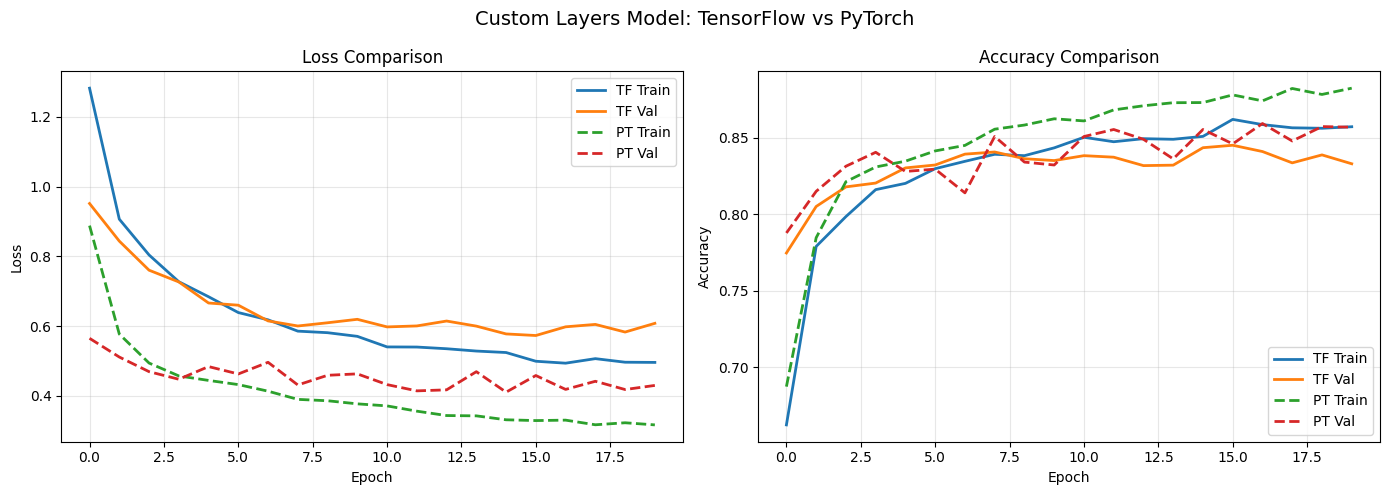

In [31]:
# Compare TensorFlow and PyTorch results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history_tf.history['loss'], label='TF Train', linewidth=2)
axes[0].plot(history_tf.history['val_loss'], label='TF Val', linewidth=2)
axes[0].plot(history_pt['train_loss'], '--', label='PT Train', linewidth=2)
axes[0].plot(history_pt['val_loss'], '--', label='PT Val', linewidth=2)
axes[0].set_title('Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(history_tf.history['accuracy'], label='TF Train', linewidth=2)
axes[1].plot(history_tf.history['val_accuracy'], label='TF Val', linewidth=2)
axes[1].plot(history_pt['train_acc'], '--', label='PT Train', linewidth=2)
axes[1].plot(history_pt['val_acc'], '--', label='PT Val', linewidth=2)
axes[1].set_title('Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Custom Layers Model: TensorFlow vs PyTorch', fontsize=14)
plt.tight_layout()
plt.show()

---

## 8. Summary and Best Practices

### Summary Table: Custom Layers

| Layer | Type | Trainable | Use Case |
|-------|------|-----------|----------|
| ExponentialLayer | Non-parametric | No | Specialized activation |
| MyDense | Parametric | Yes | Fully connected computation |
| AddGaussianNoise | Non-parametric | No | Regularization |
| MyLayerNormalization | Parametric | Yes | Normalization (RNN/Transformer) |
| MaxNormDense | Parametric | Yes | Constrained weight updates |

In [32]:
import pandas as pd

# Summary table
summary_data = {
    'Layer': ['ExponentialLayer', 'MyDense', 'AddGaussianNoise',
              'MyLayerNormalization', 'MaxNormDense'],
    'Type': ['Non-parametric', 'Parametric', 'Non-parametric',
             'Parametric', 'Parametric'],
    'Trainable': ['No', 'Yes', 'No', 'Yes', 'Yes'],
    'TensorFlow Method': ['call()', 'call() + build()', 'call() + training',
                          'call() + build()', 'call() + constraint'],
    'PyTorch Method': ['forward()', 'forward() + __init__', 'forward() + self.training',
                       'forward() + __init__', 'forward() + _apply_max_norm']
}

df = pd.DataFrame(summary_data)
print("Custom Layers Summary:")
print("=" * 100)
print(df.to_string(index=False))

Custom Layers Summary:
               Layer           Type Trainable   TensorFlow Method              PyTorch Method
    ExponentialLayer Non-parametric        No              call()                   forward()
             MyDense     Parametric       Yes    call() + build()        forward() + __init__
    AddGaussianNoise Non-parametric        No   call() + training   forward() + self.training
MyLayerNormalization     Parametric       Yes    call() + build()        forward() + __init__
        MaxNormDense     Parametric       Yes call() + constraint forward() + _apply_max_norm


### Best Practices for Custom Layers

1. **Weight Initialization**
   - Use appropriate initializers (He for ReLU, Xavier for tanh/sigmoid)
   - Make initializers configurable

2. **Training vs Inference**
   - Use `training` argument in TensorFlow's `call()`
   - Use `self.training` attribute in PyTorch's `forward()`

3. **Serialization**
   - Implement `get_config()` in TensorFlow for model saving
   - All hyperparameters should be stored for reproducibility

4. **Shape Handling**
   - Use dynamic shape computation when possible
   - Implement `compute_output_shape()` in TensorFlow

5. **Numerical Stability**
   - Add small epsilon values where division occurs
   - Handle edge cases (zero variance, etc.)

In [33]:
print("\nNotebook completed successfully!")
print("="*50)
print("Key takeaways:")
print("1. Custom layers extend framework capabilities for specialized needs")
print("2. Parametric layers have trainable weights; non-parametric layers don't")
print("3. Handle training vs inference mode for layers like noise/dropout")
print("4. Both TensorFlow and PyTorch support similar custom layer patterns")


Notebook completed successfully!
Key takeaways:
1. Custom layers extend framework capabilities for specialized needs
2. Parametric layers have trainable weights; non-parametric layers don't
3. Handle training vs inference mode for layers like noise/dropout
4. Both TensorFlow and PyTorch support similar custom layer patterns
